<a href="https://colab.research.google.com/github/dipaola-mit/Ma-AIEmployment/blob/main/Student_Voices_Students_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import auth
import gspread
from google.auth import default

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# Input and Clean Datasets

In [3]:
##PRE
sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1NT4rS3LgLJPNBd2gNYWdsH4MUTY8ZIRXweBRIp1sQZ8/edit?usp=sharing")
worksheet = sheet.sheet1  # or sheet.get_worksheet(0)

pre_df_original = pd.DataFrame(worksheet.get_all_records())
pre_df_original = pre_df_original[pre_df_original['Consent']=='Y']


In [4]:
##POST
sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1iQqTLm618IO5Yb066K7ybs1fiU0NanVtD37eb34fijw/edit?usp=sharing")
worksheet = sheet.sheet1  # or sheet.get_worksheet(0)

post_df_original = pd.DataFrame(worksheet.get_all_records())
post_df_original = post_df_original[post_df_original['Consent']=='Y']

In [5]:
##PAIRED
sheet = gc.open_by_url("https://docs.google.com/spreadsheets/d/1hYhk6d5XS8SC0c1eVtkHCMFQVAxFi-ChLqU3SVUu90k/edit?usp=sharing")
worksheet = sheet.sheet1  # or sheet.get_worksheet(0)

paired = pd.DataFrame(worksheet.get_all_records())
paired = paired[paired['Consent']=='Y']

In [6]:
##Likert scale to numbers

likert_mapping = {
    "Strongly Agree": 5,
    "Definitely Yes":5,
    "Agree": 4,
    "Probably Yes": 4,
    "Neither Agree nor Disagree": 3,
    "Neither Agree Nor Disagree": 3,
    "Maybe": 3,
    "Disagree": 2,
    "Probably Not": 2,
    "Strongly Disagree": 1,
    "Definitely Not": 1
}

pre_df_original=pre_df_original.replace(likert_mapping)
post_df_original=post_df_original.replace(likert_mapping)
paired=paired.replace(likert_mapping)

/tmp/ipykernel_4064/4018965369.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pre_df_original=pre_df_original.replace(likert_mapping)
/tmp/ipykernel_4064/4018965369.py:18: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  post_df_original=post_df_original.replace(likert_mapping)
/tmp/ipykernel_4064/4018965369.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior

In [7]:
##General Attitudes Toward AI Negative Correction

negative_cols = ['Sinister', 'Shiver', 'Suffer']
pre_df_original[negative_cols]= (5+1) - pre_df_original[negative_cols]
post_df_original[negative_cols]= (5+1) - post_df_original[negative_cols]
paired[negative_cols]= (5+1) - paired[negative_cols]

# General Attitudes Toward AI

## For Paired

In [8]:
general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']

for col in general_ai:
    if col in paired.columns:
        paired[col] = pd.to_numeric(paired[col], errors='coerce')

output_general_ai = paired[['PREPOST', 'UID'] + general_ai].copy()
output_general_ai['general_ai_mean'] = paired[general_ai].mean(axis=1)

In [9]:
output_general_ai.head(3)

,PREPOST,UID,Economic AI,Daily AI,Beneficial Apps,Sinister,Shiver,Suffer,general_ai_mean
0,PRE,1,4,4,4,3,4,5,4.000000
1,POST,1,3,3,3,4,4,5,3.666667
4,PRE,3,5,5,5,4,3,3,4.166667


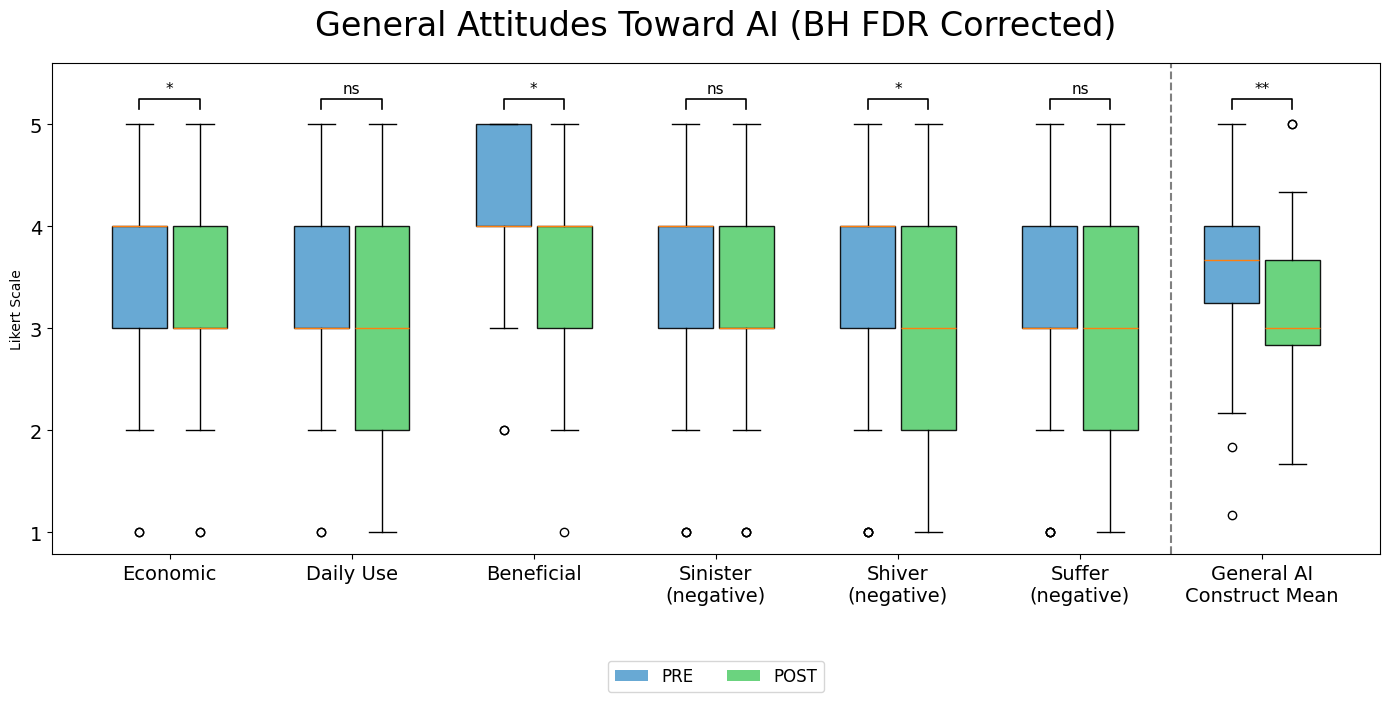

In [10]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

cols_to_plot = general_ai + ['general_ai_mean']

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_pre = np.arange(n_cols) * 3
positions_post = positions_pre + 1

all_pre, all_post = [], []
p_values_raw = []

# First pass: collect data and raw p-values
for col in cols_to_plot:
    pre_df = output_general_ai[output_general_ai['PREPOST'] == 'PRE'][['UID', col]].dropna()
    post_df = output_general_ai[output_general_ai['PREPOST'] == 'POST'][['UID', col]].dropna()
    paired_df = pre_df.merge(post_df, on='UID', suffixes=('_pre', '_post'))

    stat, p_value = stats.wilcoxon(paired_df[f'{col}_pre'], paired_df[f'{col}_post'])
    p_values_raw.append(p_value)

    pre = output_general_ai[output_general_ai['PREPOST'] == 'PRE'][col].dropna()
    post = output_general_ai[output_general_ai['PREPOST'] == 'POST'][col].dropna()
    all_pre.append(pre)
    all_post.append(post)

# Apply FDR correction
_, p_adjusted, _, _ = multipletests(p_values_raw, alpha=0.05, method='fdr_bh')

# Assign significance labels from adjusted p-values
sig_labels = []
for p_adj in p_adjusted:
    if p_adj < 0.001:
        sig_labels.append('***')
    elif p_adj < 0.01:
        sig_labels.append('**')
    elif p_adj < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot pre/post boxes
bp_pre = ax.boxplot(all_pre, positions=positions_pre, patch_artist=True,
                    widths=0.9, manage_ticks=False)
bp_post = ax.boxplot(all_post, positions=positions_post, patch_artist=True,
                     widths=0.9, manage_ticks=False)

for patch in bp_pre['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_post['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (pre, post, sig) in enumerate(zip(all_pre, all_post, sig_labels)):
    y_max = max(pre.max(), post.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_pre[i], positions_post[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_pre + positions_post) / 2
ax.set_xticks(tick_positions)
x_tick_labels = [
    'Economic',
    'Daily Use',
    'Beneficial',
    'Sinister\n(negative)',
    'Shiver\n(negative)',
    'Suffer\n(negative)',
    'General AI\nConstruct Mean'
]
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='PRE'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='POST')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.2), ncol=2)

ax.set_title('General Attitudes Toward AI (BH FDR Corrected)', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

midpoint = (positions_post[-2] + positions_pre[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

In [11]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

cols_to_plot = general_ai + ['general_ai_mean']

x_tick_labels = [
    'Economic',
    'Daily Use',
    'Beneficial',
    'Sinister (negative)',
    'Shiver (negative)',
    'Suffer (negative)',
    'General AI Construct Mean'
]

rows = []
p_values_raw = []

# First pass: run all tests and collect p-values
for col, label in zip(cols_to_plot, x_tick_labels):
    pre_df = output_general_ai[output_general_ai['PREPOST'] == 'PRE'][['UID', col]].dropna()
    post_df = output_general_ai[output_general_ai['PREPOST'] == 'POST'][['UID', col]].dropna()
    paired_df = pre_df.merge(post_df, on='UID', suffixes=('_pre', '_post'))

    stat, p_value = stats.wilcoxon(paired_df[f'{col}_pre'], paired_df[f'{col}_post'])

    pre_vals = paired_df[f'{col}_pre']
    post_vals = paired_df[f'{col}_post']

    rows.append({
        'Item': label,
        'N (paired)': len(paired_df),
        'Pre Mean (SD)': f"{pre_vals.mean():.2f} ({pre_vals.std():.2f})",
        'Post Mean (SD)': f"{post_vals.mean():.2f} ({post_vals.std():.2f})",
        'W Statistic': f"{stat:.1f}",
        '_p_raw': p_value,  # temporary, removed later
    })
    p_values_raw.append(p_value)

# Apply FDR correction across all tests
reject, p_adjusted, _, _ = multipletests(p_values_raw, alpha=0.05, method='fdr_bh')

# Second pass: assign significance based on adjusted p-values
for row, p_adj in zip(rows, p_adjusted):
    p_raw = row.pop('_p_raw')  # remove temp column

    if p_adj < 0.001:
        sig = '***'
    elif p_adj < 0.01:
        sig = '**'
    elif p_adj < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    row['p-value (raw)'] = f"{p_raw:.4f}" if p_raw >= 0.001 else "<0.001"
    row['p-value (FDR adj.)'] = f"{p_adj:.4f}" if p_adj >= 0.001 else "<0.001"
    row['Sig. (FDR)'] = sig

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Wilcoxon Signed-Rank Test: PRE vs POST — General AI Attitudes (BH FDR Corrected)") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig. (FDR)']) \
    .hide(axis='index')

/tmp/ipykernel_4064/4163879048.py:67: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig. (FDR)']) \


Item,N (paired),Pre Mean (SD),Post Mean (SD),W Statistic,p-value (raw),p-value (FDR adj.),Sig. (FDR)
Economic,51,3.73 (0.92),3.33 (1.03),126.0,0.0057,0.0137,*
Daily Use,51,3.35 (1.07),3.08 (1.13),167.0,0.0519,0.0727,ns
Beneficial,51,4.08 (0.74),3.73 (0.96),42.5,0.0074,0.0137,*
Sinister (negative),51,3.37 (0.98),3.18 (0.97),133.0,0.1454,0.1454,ns
Shiver (negative),51,3.59 (1.08),3.14 (1.10),108.0,0.0078,0.0137,*
Suffer (negative),51,3.41 (1.17),3.12 (1.21),181.5,0.1078,0.1257,ns
General AI Construct Mean,51,3.59 (0.70),3.26 (0.71),198.0,<0.001,0.0021,**


##Pre Policy vs. No Policy

In [12]:
general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']

for col in general_ai:
    if col in pre_df_original.columns:
        pre_df_original[col] = pd.to_numeric(pre_df_original[col], errors='coerce')

output_general_ai_pre = pre_df_original[['School'] + general_ai].copy()
output_general_ai_pre['general_ai_mean'] = pre_df_original[general_ai].mean(axis=1)

In [13]:
# Define policy schools
policy_schools = ['BHS', 'RHS', 'PC', 'UA']

import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']
cols_to_test = general_ai + ['general_ai_mean']

x_tick_labels = [
    'Economic',
    'Daily Use',
    'Beneficial',
    'Sinister (negative)',
    'Shiver (negative)',
    'Suffer (negative)',
    'General AI Construct Mean'
]

# Split into policy vs. non-policy
policy_df = output_general_ai_pre[output_general_ai_pre['School'].isin(policy_schools)]
non_policy_df = output_general_ai_pre[~output_general_ai_pre['School'].isin(policy_schools)]

rows = []
p_values_raw = []

# First pass: run all tests and collect p-values
for col, label in zip(cols_to_test, x_tick_labels):
    policy_vals = policy_df[col].dropna()
    non_policy_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_policy_vals, alternative='two-sided')
    p_values_raw.append(p_value)

    rows.append({
        'Item': label,
        'Policy N': len(policy_vals),
        'Non-Policy N': len(non_policy_vals),
        'Policy Mean (SD)': f"{policy_vals.mean():.2f} ({policy_vals.std():.2f})",
        'Non-Policy Mean (SD)': f"{non_policy_vals.mean():.2f} ({non_policy_vals.std():.2f})",
        'U Statistic': f"{stat:.1f}",
        '_p_raw': p_value,  # temporary
    })

# Apply FDR correction
_, p_adjusted, _, _ = multipletests(p_values_raw, alpha=0.05, method='fdr_bh')

# Second pass: assign significance from adjusted p-values
for row, p_adj in zip(rows, p_adjusted):
    p_raw = row.pop('_p_raw')

    if p_adj < 0.001:
        sig = '***'
    elif p_adj < 0.01:
        sig = '**'
    elif p_adj < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    row['p-value (raw)'] = f"{p_raw:.4f}" if p_raw >= 0.001 else "<0.001"
    row['p-value (FDR adj.)'] = f"{p_adj:.4f}" if p_adj >= 0.001 else "<0.001"
    row['Sig. (FDR)'] = sig

mwu_df = pd.DataFrame(rows)

mwu_df.style \
    .set_caption("Mann-Whitney U Test: Policy vs. Non-Policy Schools — General AI Attitudes (PRE, BH FDR Corrected)") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig. (FDR)']) \
    .hide(axis='index')

/tmp/ipykernel_4064/2544552796.py:72: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig. (FDR)']) \


Item,Policy N,Non-Policy N,Policy Mean (SD),Non-Policy Mean (SD),U Statistic,p-value (raw),p-value (FDR adj.),Sig. (FDR)
Economic,11,55,3.45 (1.21),3.71 (0.85),272.0,0.5780,0.6404,ns
Daily Use,11,55,2.91 (0.94),3.47 (1.00),195.0,0.0541,0.3214,ns
Beneficial,11,55,4.18 (0.60),4.04 (0.77),327.5,0.6404,0.6404,ns
Sinister (negative),11,55,3.18 (1.17),3.42 (0.94),268.0,0.5322,0.6404,ns
Shiver (negative),11,55,2.82 (1.54),3.60 (0.97),224.0,0.1594,0.3397,ns
Suffer (negative),11,55,2.82 (1.54),3.44 (1.12),229.0,0.1941,0.3397,ns
General AI Construct Mean,11,55,3.23 (0.83),3.61 (0.67),204.5,0.0918,0.3214,ns


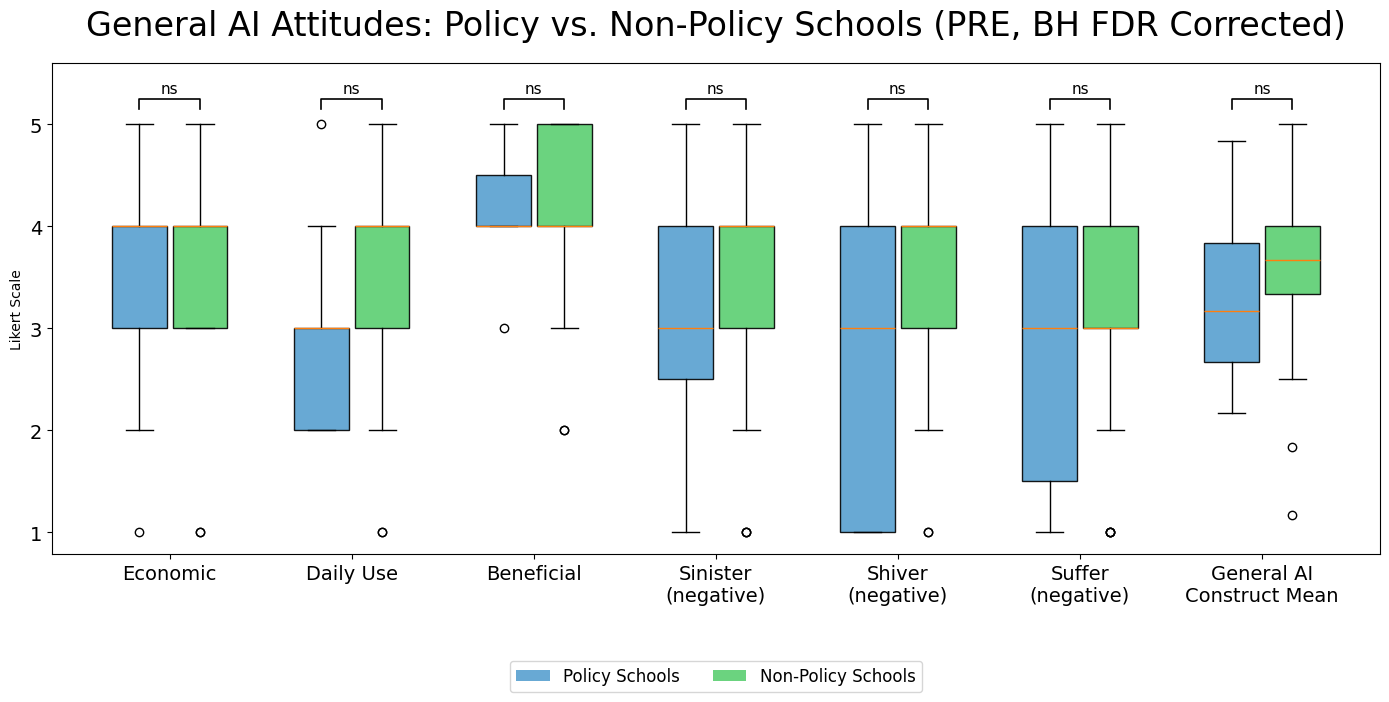

In [14]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']
cols_to_plot = general_ai + ['general_ai_mean']

x_tick_labels = [
    'Economic',
    'Daily Use',
    'Beneficial',
    'Sinister\n(negative)',
    'Shiver\n(negative)',
    'Suffer\n(negative)',
    'General AI\nConstruct Mean'
]

policy_df = output_general_ai_pre[output_general_ai_pre['School'].isin(policy_schools)]
non_policy_df = output_general_ai_pre[~output_general_ai_pre['School'].isin(policy_schools)]

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_policy = np.arange(n_cols) * 3
positions_non = positions_policy + 1

all_policy, all_non = [], []
p_values_raw = []

# First pass: collect data and raw p-values
for col in cols_to_plot:
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')
    p_values_raw.append(p_value)

    all_policy.append(policy_vals)
    all_non.append(non_vals)

# Apply FDR correction
_, p_adjusted, _, _ = multipletests(p_values_raw, alpha=0.05, method='fdr_bh')

# Assign significance from adjusted p-values
sig_labels = []
for p_adj in p_adjusted:
    if p_adj < 0.001:
        sig_labels.append('***')
    elif p_adj < 0.01:
        sig_labels.append('**')
    elif p_adj < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_policy = ax.boxplot(all_policy, positions=positions_policy, patch_artist=True,
                       widths=0.9, manage_ticks=False)
bp_non = ax.boxplot(all_non, positions=positions_non, patch_artist=True,
                    widths=0.9, manage_ticks=False)

for patch in bp_policy['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_non['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (policy, non, sig) in enumerate(zip(all_policy, all_non, sig_labels)):
    y_max = max(policy.max(), non.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_policy[i], positions_non[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_policy + positions_non) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='Policy Schools'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='Non-Policy Schools')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.2), ncol=2)

ax.set_title('General AI Attitudes: Policy vs. Non-Policy Schools (PRE, BH FDR Corrected)', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

In [15]:
policy_n = policy_df.shape[0]
non_policy_n = non_policy_df.shape[0]

print(f"Policy schools N: {policy_n}")
print(f"Non-policy schools N: {non_policy_n}")

Policy schools N: 11
Non-policy schools N: 55


In [16]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']
cols_to_plot = general_ai + ['general_ai_mean']

x_tick_labels = [
    'Economic',
    'Daily Use',
    'Beneficial',
    'Sinister (negative)',
    'Shiver (negative)',
    'Suffer (negative)',
    'General AI Construct Mean'
]

policy_df = output_general_ai_pre[output_general_ai_pre['School'].isin(policy_schools)]
non_policy_df = output_general_ai_pre[~output_general_ai_pre['School'].isin(policy_schools)]

rows = []
p_values_raw = []

# First pass: run all tests and collect p-values
for col, label in zip(cols_to_plot, x_tick_labels):
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')
    p_values_raw.append(p_value)

    rows.append({
        'Item': label,
        'N (Policy)': len(policy_vals),
        'N (Non-Policy)': len(non_vals),
        'Policy Mean (SD)': f"{policy_vals.mean():.2f} ({policy_vals.std():.2f})",
        'Non-Policy Mean (SD)': f"{non_vals.mean():.2f} ({non_vals.std():.2f})",
        'U Statistic': f"{stat:.1f}",
        '_p_raw': p_value,
    })

# Apply FDR correction
_, p_adjusted, _, _ = multipletests(p_values_raw, alpha=0.05, method='fdr_bh')

# Second pass: assign significance from adjusted p-values
for row, p_adj in zip(rows, p_adjusted):
    p_raw = row.pop('_p_raw')

    if p_adj < 0.001:
        sig = '***'
    elif p_adj < 0.01:
        sig = '**'
    elif p_adj < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    row['p-value (raw)'] = f"{p_raw:.4f}" if p_raw >= 0.001 else "<0.001"
    row['p-value (FDR adj.)'] = f"{p_adj:.4f}" if p_adj >= 0.001 else "<0.001"
    row['Sig. (FDR)'] = sig

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Mann-Whitney U Test: Policy vs. Non-Policy Schools — General AI Attitudes (PRE, BH FDR Corrected)") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig. (FDR)']) \
    .hide(axis='index')

/tmp/ipykernel_4064/1126366663.py:68: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig. (FDR)']) \


Item,N (Policy),N (Non-Policy),Policy Mean (SD),Non-Policy Mean (SD),U Statistic,p-value (raw),p-value (FDR adj.),Sig. (FDR)
Economic,11,55,3.45 (1.21),3.71 (0.85),272.0,0.5780,0.6404,ns
Daily Use,11,55,2.91 (0.94),3.47 (1.00),195.0,0.0541,0.3214,ns
Beneficial,11,55,4.18 (0.60),4.04 (0.77),327.5,0.6404,0.6404,ns
Sinister (negative),11,55,3.18 (1.17),3.42 (0.94),268.0,0.5322,0.6404,ns
Shiver (negative),11,55,2.82 (1.54),3.60 (0.97),224.0,0.1594,0.3397,ns
Suffer (negative),11,55,2.82 (1.54),3.44 (1.12),229.0,0.1941,0.3397,ns
General AI Construct Mean,11,55,3.23 (0.83),3.61 (0.67),204.5,0.0918,0.3214,ns


## Post Policy vs. No Policy

In [17]:
general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']

for col in general_ai:
    if col in post_df_original.columns:
        post_df_original[col] = pd.to_numeric(post_df_original[col], errors='coerce')

output_general_ai_post = post_df_original[['School'] + general_ai].copy()
output_general_ai_post['general_ai_mean'] = post_df_original[general_ai].mean(axis=1)

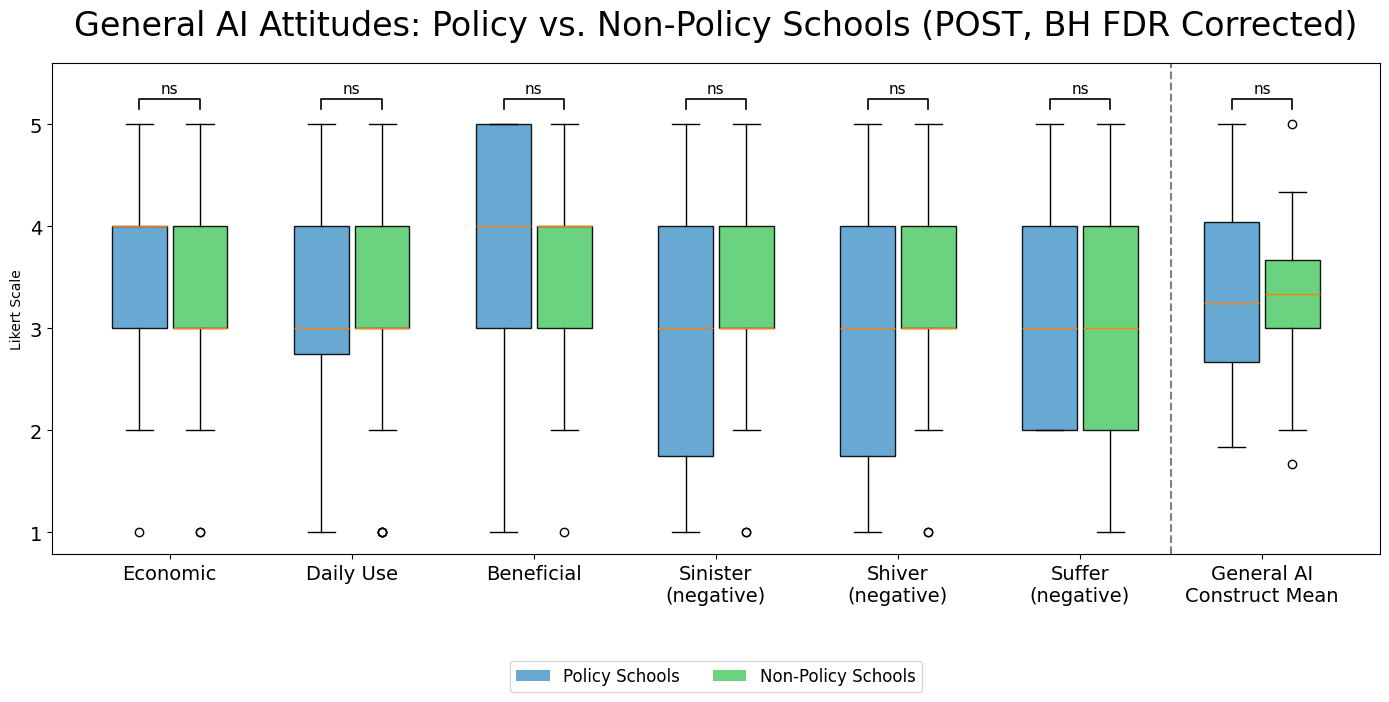

In [18]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']
cols_to_plot = general_ai + ['general_ai_mean']

x_tick_labels = [
    'Economic',
    'Daily Use',
    'Beneficial',
    'Sinister\n(negative)',
    'Shiver\n(negative)',
    'Suffer\n(negative)',
    'General AI\nConstruct Mean'
]

policy_df = output_general_ai_post[output_general_ai_post['School'].isin(policy_schools)]
non_policy_df = output_general_ai_post[~output_general_ai_post['School'].isin(policy_schools)]

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_policy = np.arange(n_cols) * 3
positions_non = positions_policy + 1

all_policy, all_non = [], []
p_values_raw = []

# First pass: collect data and raw p-values
for col in cols_to_plot:
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')
    p_values_raw.append(p_value)

    all_policy.append(policy_vals)
    all_non.append(non_vals)

# Apply FDR correction
_, p_adjusted, _, _ = multipletests(p_values_raw, alpha=0.05, method='fdr_bh')

# Assign significance from adjusted p-values
sig_labels = []
for p_adj in p_adjusted:
    if p_adj < 0.001:
        sig_labels.append('***')
    elif p_adj < 0.01:
        sig_labels.append('**')
    elif p_adj < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_policy = ax.boxplot(all_policy, positions=positions_policy, patch_artist=True,
                       widths=0.9, manage_ticks=False)
bp_non = ax.boxplot(all_non, positions=positions_non, patch_artist=True,
                    widths=0.9, manage_ticks=False)

for patch in bp_policy['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_non['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (policy, non, sig) in enumerate(zip(all_policy, all_non, sig_labels)):
    y_max = max(policy.max(), non.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_policy[i], positions_non[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_policy + positions_non) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='Policy Schools'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='Non-Policy Schools')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.2), ncol=2)

# Title
ax.set_title('General AI Attitudes: Policy vs. Non-Policy Schools (POST, BH FDR Corrected)', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

# Vertical dashed line before Construct Mean
midpoint = (positions_non[-2] + positions_policy[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

In [19]:
policy_n = policy_df.shape[0]
non_policy_n = non_policy_df.shape[0]

print(f"Policy schools N: {policy_n}")
print(f"Non-policy schools N: {non_policy_n}")

Policy schools N: 20
Non-policy schools N: 51


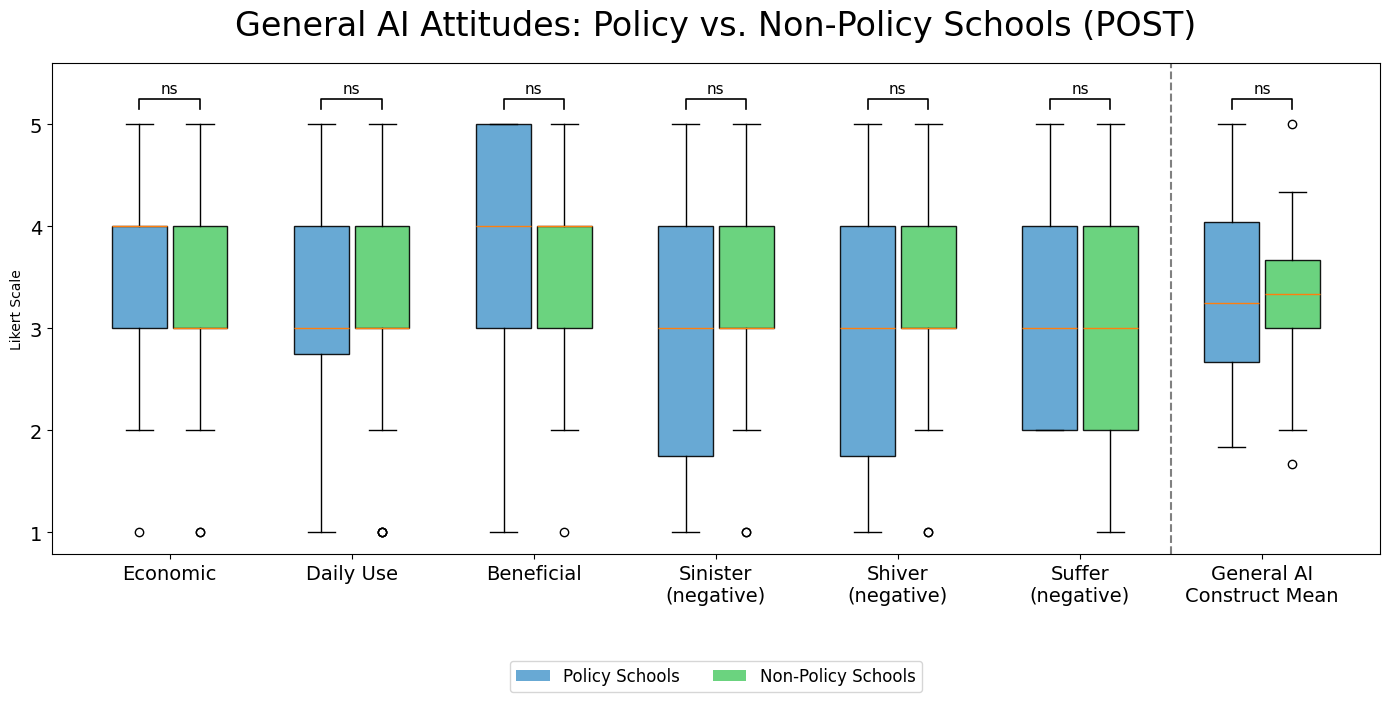

In [20]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch

general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']
cols_to_plot = general_ai + ['general_ai_mean']

x_tick_labels = [
    'Economic',
    'Daily Use',
    'Beneficial',
    'Sinister\n(negative)',
    'Shiver\n(negative)',
    'Suffer\n(negative)',
    'General AI\nConstruct Mean'
]

policy_df = output_general_ai_post[output_general_ai_post['School'].isin(policy_schools)]
non_policy_df = output_general_ai_post[~output_general_ai_post['School'].isin(policy_schools)]

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_policy = np.arange(n_cols) * 3
positions_non = positions_policy + 1

all_policy, all_non, sig_labels = [], [], []

for col in cols_to_plot:
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    all_policy.append(policy_vals)
    all_non.append(non_vals)

    if p_value < 0.001:
        sig_labels.append('***')
    elif p_value < 0.01:
        sig_labels.append('**')
    elif p_value < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_policy = ax.boxplot(all_policy, positions=positions_policy, patch_artist=True,
                       widths=0.9, manage_ticks=False)
bp_non = ax.boxplot(all_non, positions=positions_non, patch_artist=True,
                    widths=0.9, manage_ticks=False)

for patch in bp_policy['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_non['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (policy, non, sig) in enumerate(zip(all_policy, all_non, sig_labels)):
    y_max = max(policy.max(), non.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_policy[i], positions_non[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_policy + positions_non) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='Policy Schools'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='Non-Policy Schools')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.2), ncol=2)

# Title
ax.set_title('General AI Attitudes: Policy vs. Non-Policy Schools (POST)', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

# Vertical dashed line before Construct Mean
midpoint = (positions_non[-2] + positions_policy[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
plt.show()

In [21]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

general_ai = ['Economic AI', 'Daily AI', 'Beneficial Apps', 'Sinister', 'Shiver', 'Suffer']
cols_to_plot = general_ai + ['general_ai_mean']

x_tick_labels = [
    'Economic',
    'Daily Use',
    'Beneficial',
    'Sinister (negative)',
    'Shiver (negative)',
    'Suffer (negative)',
    'General AI Construct Mean'
]

policy_df = output_general_ai_post[output_general_ai_post['School'].isin(policy_schools)]
non_policy_df = output_general_ai_post[~output_general_ai_post['School'].isin(policy_schools)]

rows = []
p_values_raw = []

# First pass: run all tests and collect p-values
for col, label in zip(cols_to_plot, x_tick_labels):
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')
    p_values_raw.append(p_value)

    rows.append({
        'Item': label,
        'N (Policy)': len(policy_vals),
        'N (Non-Policy)': len(non_vals),
        'Policy Mean (SD)': f"{policy_vals.mean():.2f} ({policy_vals.std():.2f})",
        'Non-Policy Mean (SD)': f"{non_vals.mean():.2f} ({non_vals.std():.2f})",
        'U Statistic': f"{stat:.1f}",
        '_p_raw': p_value,
    })

# Apply FDR correction
_, p_adjusted, _, _ = multipletests(p_values_raw, alpha=0.05, method='fdr_bh')

# Second pass: assign significance from adjusted p-values
for row, p_adj in zip(rows, p_adjusted):
    p_raw = row.pop('_p_raw')

    if p_adj < 0.001:
        sig = '***'
    elif p_adj < 0.01:
        sig = '**'
    elif p_adj < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    row['p-value (raw)'] = f"{p_raw:.4f}" if p_raw >= 0.001 else "<0.001"
    row['p-value (FDR adj.)'] = f"{p_adj:.4f}" if p_adj >= 0.001 else "<0.001"
    row['Sig. (FDR)'] = sig

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Mann-Whitney U Test: Policy vs. Non-Policy Schools — General AI Attitudes (POST, BH FDR Corrected)") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig. (FDR)']) \
    .hide(axis='index')

/tmp/ipykernel_4064/2913886951.py:68: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig. (FDR)']) \


Item,N (Policy),N (Non-Policy),Policy Mean (SD),Non-Policy Mean (SD),U Statistic,p-value (raw),p-value (FDR adj.),Sig. (FDR)
Economic,20,51,3.65 (1.09),3.33 (0.95),616.5,0.1541,0.5754,ns
Daily Use,20,51,3.15 (1.27),3.20 (1.10),506.5,0.9682,0.9894,ns
Beneficial,20,51,4.00 (1.17),3.73 (0.92),613.5,0.1644,0.5754,ns
Sinister (negative),20,51,2.95 (1.36),3.16 (0.90),488.0,0.7719,0.9894,ns
Shiver (negative),20,51,3.00 (1.49),3.22 (1.03),476.5,0.6606,0.9894,ns
Suffer (negative),20,51,3.15 (1.09),3.14 (1.11),508.5,0.9894,0.9894,ns
General AI Construct Mean,20,51,3.32 (0.91),3.29 (0.63),495.5,0.8571,0.9894,ns


# AI Literacy

In [22]:
apply_ai = ['Operate', 'Use Easier', 'Meaningfully Goals']
understand_ai = ['Topic', 'Definitions', 'Limitations Opportunities', 'Assess Advantages', 'New Uses', 'Future Uses']
detect_ai = ['Dealing', 'Distinguish AI', 'Distinguish Human']
ai_ethics = ['Weigh', 'Incorporate', 'Ethical Implications']

## For Paired

In [23]:
output_paired_ailit = pd.DataFrame({
    'PREPOST': paired['PREPOST'],
    'UID': paired['UID'],
    'apply_ai': paired[apply_ai].mean(axis=1),
    'understand_ai': paired[understand_ai].mean(axis=1),
    'detect_ai': paired[detect_ai].mean(axis=1),
    'ai_ethics': paired[ai_ethics].mean(axis=1),
})

output_paired_ailit['ai_lit_mean'] = output_paired_ailit[['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics']].mean(axis=1)

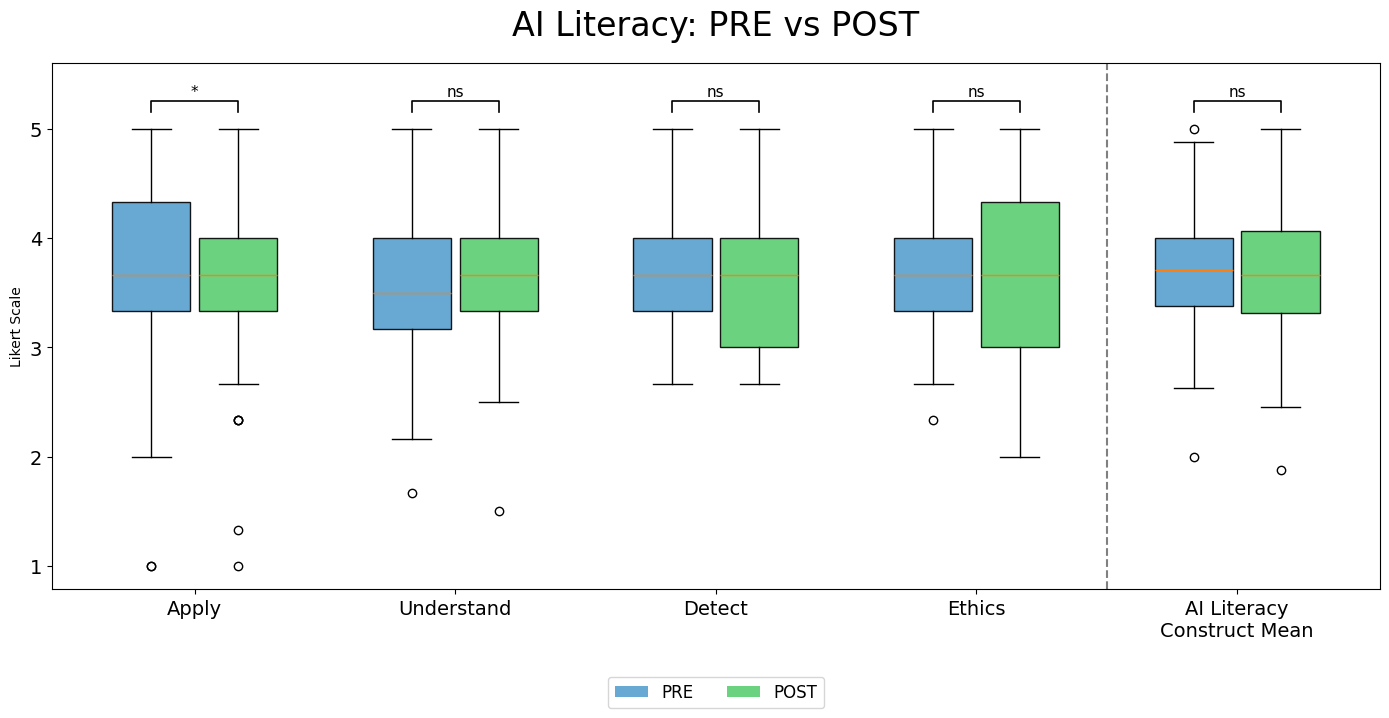

In [24]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch

cols_to_plot = ['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics', 'ai_lit_mean']

x_tick_labels = [
    'Apply',
    'Understand',
    'Detect',
    'Ethics',
    'AI Literacy\nConstruct Mean'
]

pre = output_paired_ailit[output_paired_ailit['PREPOST'] == 'PRE']
post = output_paired_ailit[output_paired_ailit['PREPOST'] == 'POST']

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_pre = np.arange(n_cols) * 3
positions_post = positions_pre + 1

all_pre, all_post, sig_labels = [], [], []

for col in cols_to_plot:
    pre_df = pre[['UID', col]].dropna()
    post_df = post[['UID', col]].dropna()
    paired_df = pre_df.merge(post_df, on='UID', suffixes=('_pre', '_post'))

    stat, p_value = stats.wilcoxon(paired_df[f'{col}_pre'], paired_df[f'{col}_post'])

    all_pre.append(paired_df[f'{col}_pre'])
    all_post.append(paired_df[f'{col}_post'])

    if p_value < 0.001:
        sig_labels.append('***')
    elif p_value < 0.01:
        sig_labels.append('**')
    elif p_value < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_pre = ax.boxplot(all_pre, positions=positions_pre, patch_artist=True,
                    widths=0.9, manage_ticks=False)
bp_post = ax.boxplot(all_post, positions=positions_post, patch_artist=True,
                     widths=0.9, manage_ticks=False)

for patch in bp_pre['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_post['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (pre_v, post_v, sig) in enumerate(zip(all_pre, all_post, sig_labels)):
    y_max = max(pre_v.max(), post_v.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_pre[i], positions_post[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_pre + positions_post) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='PRE'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='POST')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=2)

ax.set_title('AI Literacy: PRE vs POST', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

# Vertical dashed line before Construct Mean
midpoint = (positions_post[-2] + positions_pre[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [25]:
import pandas as pd
import scipy.stats as stats

cols_to_plot = ['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics', 'ai_lit_mean']

x_tick_labels = [
    'Apply',
    'Understand',
    'Detect',
    'Ethics',
    'AI Literacy Construct Mean'
]

rows = []

for col, label in zip(cols_to_plot, x_tick_labels):
    pre_df = output_paired_ailit[output_paired_ailit['PREPOST'] == 'PRE'][['UID', col]].dropna()
    post_df = output_paired_ailit[output_paired_ailit['PREPOST'] == 'POST'][['UID', col]].dropna()
    paired_df = pre_df.merge(post_df, on='UID', suffixes=('_pre', '_post'))

    stat, p_value = stats.wilcoxon(paired_df[f'{col}_pre'], paired_df[f'{col}_post'])

    pre_vals = paired_df[f'{col}_pre']
    post_vals = paired_df[f'{col}_post']

    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    rows.append({
        'Item': label,
        'N (paired)': len(paired_df),
        'Pre Mean (SD)': f"{pre_vals.mean():.2f} ({pre_vals.std():.2f})",
        'Post Mean (SD)': f"{post_vals.mean():.2f} ({post_vals.std():.2f})",
        'W Statistic': f"{stat:.1f}",
        'p-value': f"{p_value:.4f}" if p_value >= 0.001 else "<0.001",
        'Sig.': sig
    })

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Wilcoxon Signed-Rank Test: PRE vs POST — AI Literacy") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \
    .hide(axis='index')

/tmp/ipykernel_4064/1253881940.py:51: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \


Item,N (paired),Pre Mean (SD),Post Mean (SD),W Statistic,p-value,Sig.
Apply,51,3.71 (0.92),3.52 (0.80),191.0,0.0415,*
Understand,51,3.58 (0.70),3.69 (0.69),300.0,0.1385,ns
Detect,51,3.80 (0.57),3.63 (0.57),247.5,0.0733,ns
Ethics,51,3.74 (0.67),3.73 (0.83),269.0,0.8362,ns
AI Literacy Construct Mean,51,3.71 (0.55),3.64 (0.58),505.5,0.2025,ns


## Pre Policy vs. No Policy

In [26]:
output_pre_ailit = pd.DataFrame({
    'School': pre_df_original['School'],
    'apply_ai': pre_df_original[apply_ai].mean(axis=1),
    'understand_ai': pre_df_original[understand_ai].mean(axis=1),
    'detect_ai': pre_df_original[detect_ai].mean(axis=1),
    'ai_ethics': pre_df_original[ai_ethics].mean(axis=1),
})

output_pre_ailit['ai_lit_mean'] = output_pre_ailit[['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics']].mean(axis=1)

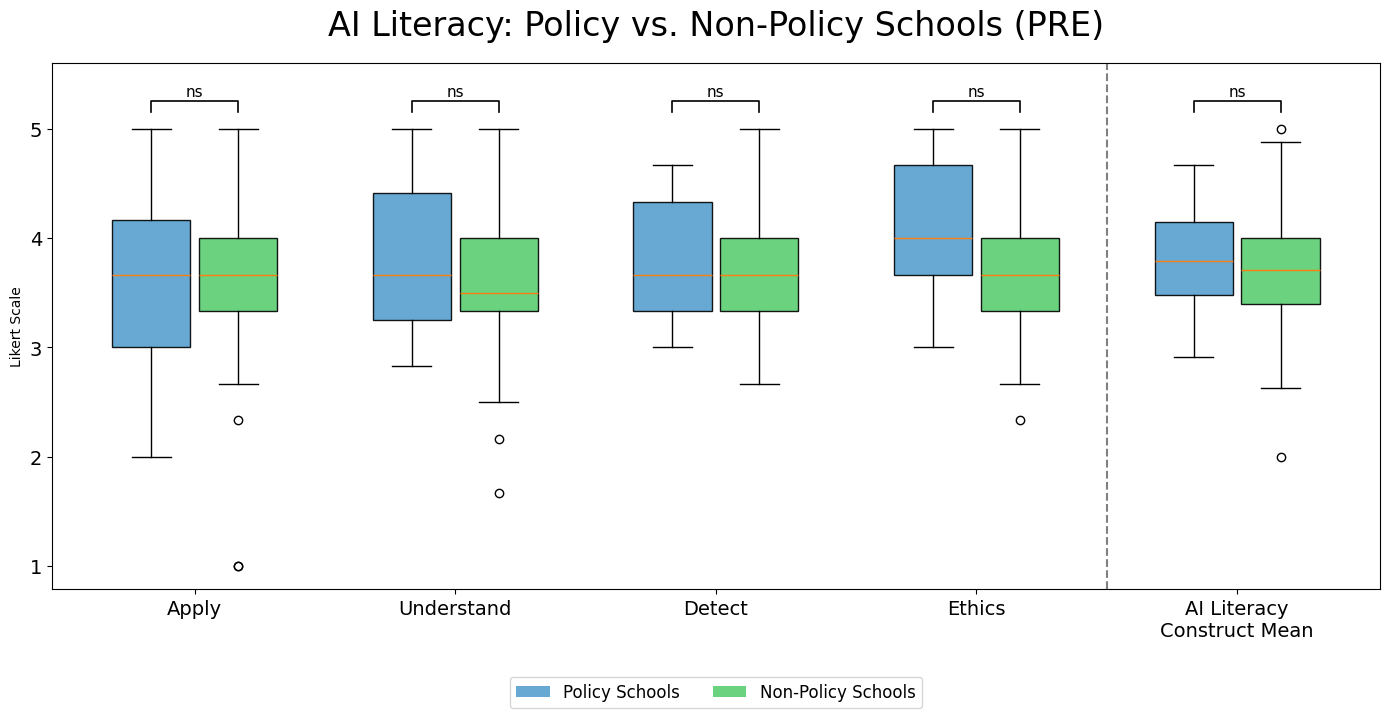

In [27]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch

# Add mean column if not already present
output_pre_ailit['ai_lit_mean'] = output_pre_ailit[['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics']].mean(axis=1)

cols_to_plot = ['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics', 'ai_lit_mean']

x_tick_labels = [
    'Apply',
    'Understand',
    'Detect',
    'Ethics',
    'AI Literacy\nConstruct Mean'
]

policy_df = output_pre_ailit[output_pre_ailit['School'].isin(policy_schools)]
non_policy_df = output_pre_ailit[~output_pre_ailit['School'].isin(policy_schools)]

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_policy = np.arange(n_cols) * 3
positions_non = positions_policy + 1

all_policy, all_non, sig_labels = [], [], []

for col in cols_to_plot:
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    all_policy.append(policy_vals)
    all_non.append(non_vals)

    if p_value < 0.001:
        sig_labels.append('***')
    elif p_value < 0.01:
        sig_labels.append('**')
    elif p_value < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_policy = ax.boxplot(all_policy, positions=positions_policy, patch_artist=True,
                       widths=0.9, manage_ticks=False)
bp_non = ax.boxplot(all_non, positions=positions_non, patch_artist=True,
                    widths=0.9, manage_ticks=False)

for patch in bp_policy['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_non['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (policy, non, sig) in enumerate(zip(all_policy, all_non, sig_labels)):
    y_max = max(policy.max(), non.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_policy[i], positions_non[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_policy + positions_non) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='Policy Schools'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='Non-Policy Schools')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=2)

ax.set_title('AI Literacy: Policy vs. Non-Policy Schools (PRE)', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

# Vertical dashed line before Construct Mean
midpoint = (positions_non[-2] + positions_policy[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [28]:
import pandas as pd
import scipy.stats as stats

# Add mean column if not already present
output_pre_ailit['ai_lit_mean'] = output_pre_ailit[['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics']].mean(axis=1)

cols_to_plot = ['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics', 'ai_lit_mean']

x_tick_labels = [
    'Apply',
    'Understand',
    'Detect',
    'Ethics',
    'AI Literacy Construct Mean'
]

policy_df = output_pre_ailit[output_pre_ailit['School'].isin(policy_schools)]
non_policy_df = output_pre_ailit[~output_pre_ailit['School'].isin(policy_schools)]

rows = []

for col, label in zip(cols_to_plot, x_tick_labels):
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    rows.append({
        'Item': label,
        'N (Policy)': len(policy_vals),
        'N (Non-Policy)': len(non_vals),
        'Policy Mean (SD)': f"{policy_vals.mean():.2f} ({policy_vals.std():.2f})",
        'Non-Policy Mean (SD)': f"{non_vals.mean():.2f} ({non_vals.std():.2f})",
        'U Statistic': f"{stat:.1f}",
        'p-value': f"{p_value:.4f}" if p_value >= 0.001 else "<0.001",
        'Sig.': sig
    })

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Mann-Whitney U Test: Policy vs. Non-Policy Schools — AI Literacy (PRE)") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \
    .hide(axis='index')

/tmp/ipykernel_4064/1163385517.py:54: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \


Item,N (Policy),N (Non-Policy),Policy Mean (SD),Non-Policy Mean (SD),U Statistic,p-value,Sig.
Apply,11,55,3.55 (1.04),3.73 (0.80),263.0,0.4962,ns
Understand,11,55,3.82 (0.72),3.61 (0.66),340.5,0.5162,ns
Detect,11,55,3.82 (0.54),3.84 (0.57),300.0,0.9721,ns
Ethics,11,55,4.09 (0.75),3.68 (0.63),400.5,0.0885,ns
AI Literacy Construct Mean,11,55,3.82 (0.52),3.71 (0.51),343.0,0.4911,ns


## POST Policy vs No Policy

In [29]:
output_post_ailit =pd.DataFrame({
    'School': post_df_original['School'],
    'apply_ai': post_df_original[apply_ai].mean(axis=1),
    'understand_ai': post_df_original[understand_ai].mean(axis=1),
    'detect_ai': post_df_original[detect_ai].mean(axis=1),
    'ai_ethics': post_df_original[ai_ethics].mean(axis=1),
})

output_post_ailit['ai_lit_mean'] = output_post_ailit[['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics']].mean(axis=1)

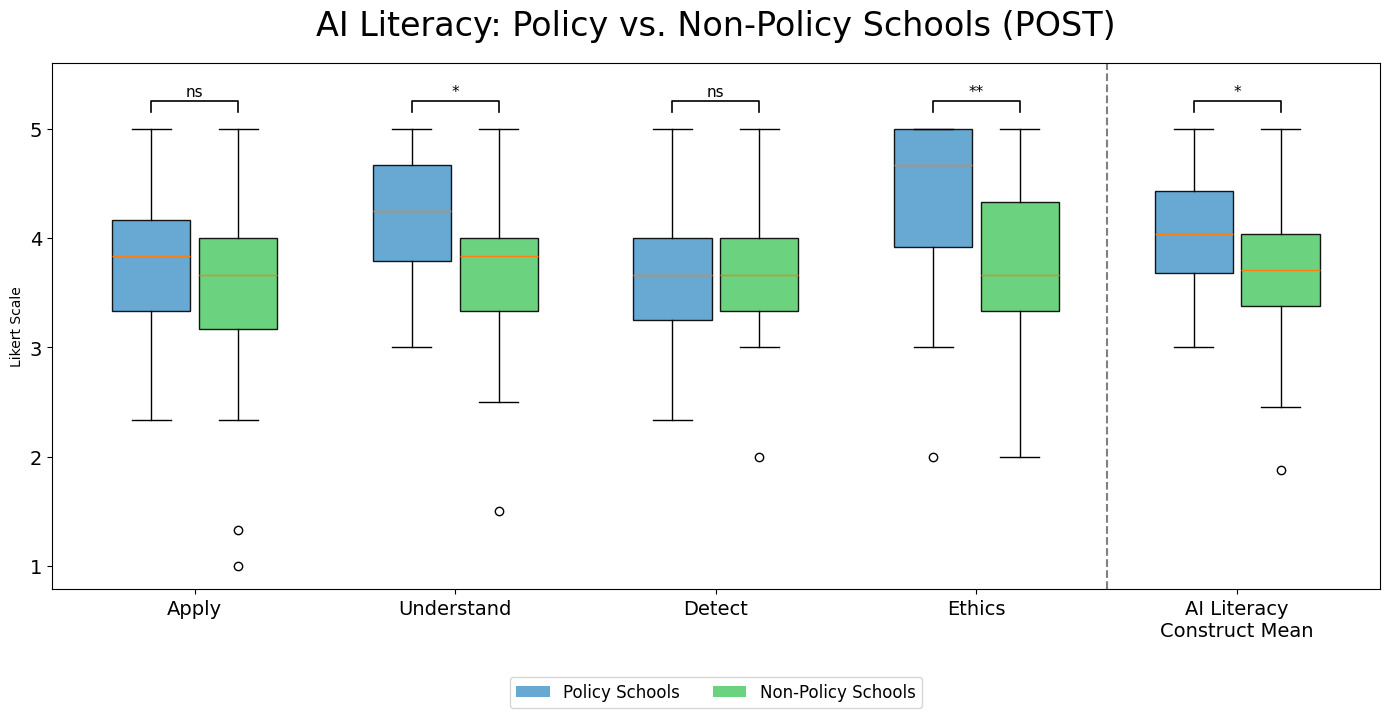

In [30]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch

# Add mean column if not already present
output_post_ailit['ai_lit_mean'] = output_post_ailit[['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics']].mean(axis=1)

cols_to_plot = ['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics', 'ai_lit_mean']

x_tick_labels = [
    'Apply',
    'Understand',
    'Detect',
    'Ethics',
    'AI Literacy\nConstruct Mean'
]

policy_df = output_post_ailit[output_post_ailit['School'].isin(policy_schools)]
non_policy_df = output_post_ailit[~output_post_ailit['School'].isin(policy_schools)]

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_policy = np.arange(n_cols) * 3
positions_non = positions_policy + 1

all_policy, all_non, sig_labels = [], [], []

for col in cols_to_plot:
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    all_policy.append(policy_vals)
    all_non.append(non_vals)

    if p_value < 0.001:
        sig_labels.append('***')
    elif p_value < 0.01:
        sig_labels.append('**')
    elif p_value < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_policy = ax.boxplot(all_policy, positions=positions_policy, patch_artist=True,
                       widths=0.9, manage_ticks=False)
bp_non = ax.boxplot(all_non, positions=positions_non, patch_artist=True,
                    widths=0.9, manage_ticks=False)

for patch in bp_policy['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_non['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (policy, non, sig) in enumerate(zip(all_policy, all_non, sig_labels)):
    y_max = max(policy.max(), non.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_policy[i], positions_non[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_policy + positions_non) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='Policy Schools'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='Non-Policy Schools')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=2)

ax.set_title('AI Literacy: Policy vs. Non-Policy Schools (POST)', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

# Vertical dashed line before Construct Mean
midpoint = (positions_non[-2] + positions_policy[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [31]:
import pandas as pd
import scipy.stats as stats

# Add mean column if not already present
output_post_ailit['ai_lit_mean'] = output_post_ailit[['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics']].mean(axis=1)

cols_to_plot = ['apply_ai', 'understand_ai', 'detect_ai', 'ai_ethics', 'ai_lit_mean']

x_tick_labels = [
    'Apply',
    'Understand',
    'Detect',
    'Ethics',
    'AI Literacy Construct Mean'
]

policy_df = output_post_ailit[output_post_ailit['School'].isin(policy_schools)]
non_policy_df = output_post_ailit[~output_post_ailit['School'].isin(policy_schools)]

rows = []

for col, label in zip(cols_to_plot, x_tick_labels):
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    rows.append({
        'Item': label,
        'N (Policy)': len(policy_vals),
        'N (Non-Policy)': len(non_vals),
        'Policy Mean (SD)': f"{policy_vals.mean():.2f} ({policy_vals.std():.2f})",
        'Non-Policy Mean (SD)': f"{non_vals.mean():.2f} ({non_vals.std():.2f})",
        'U Statistic': f"{stat:.1f}",
        'p-value': f"{p_value:.4f}" if p_value >= 0.001 else "<0.001",
        'Sig.': sig
    })

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Mann-Whitney U Test: Policy vs. Non-Policy Schools — AI Literacy (POST)") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \
    .hide(axis='index')

/tmp/ipykernel_4064/2446684070.py:54: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \


Item,N (Policy),N (Non-Policy),Policy Mean (SD),Non-Policy Mean (SD),U Statistic,p-value,Sig.
Apply,20,51,3.78 (0.84),3.50 (0.75),587.0,0.3201,ns
Understand,20,51,4.18 (0.59),3.72 (0.69),702.0,0.0140,*
Detect,20,51,3.68 (0.70),3.73 (0.61),479.5,0.6966,ns
Ethics,20,51,4.27 (0.83),3.73 (0.82),710.5,0.0099,**
AI Literacy Construct Mean,20,51,3.98 (0.54),3.67 (0.58),667.5,0.0447,*


# Civic Efficacy

In [32]:
civic_duty = ['Reduce Hunger', 'Treat Fairly', 'Better Place', 'Help Other']
civic_skills = ['Contact News', 'Contact Official', 'Opinion Letter', 'Express Views']
nh_social_connection = ['Care About Me', 'Matter', 'Adults Listen', 'Adults Important']
future_participation = ['Volunteer', 'Vote Election', 'Stand Up']

## For Paired

In [33]:
all_civic_cols = civic_duty + civic_skills + nh_social_connection + future_participation

for col in all_civic_cols:
    if col in paired.columns:
        paired[col] = pd.to_numeric(paired[col], errors='coerce')

output_paired_civic = pd.DataFrame({
    'PREPOST': paired['PREPOST'],
    'UID': paired['UID'],
    'civic_duty': paired[civic_duty].mean(axis=1),
    'civic_skills': paired[civic_skills].mean(axis=1),
    'nh_social_connection': paired[nh_social_connection].mean(axis=1),
    'future_participation': paired[future_participation].mean(axis=1),
})

output_paired_civic['ai_civic_mean'] = output_paired_civic[['civic_duty','civic_skills', 'nh_social_connection']].mean(axis=1)

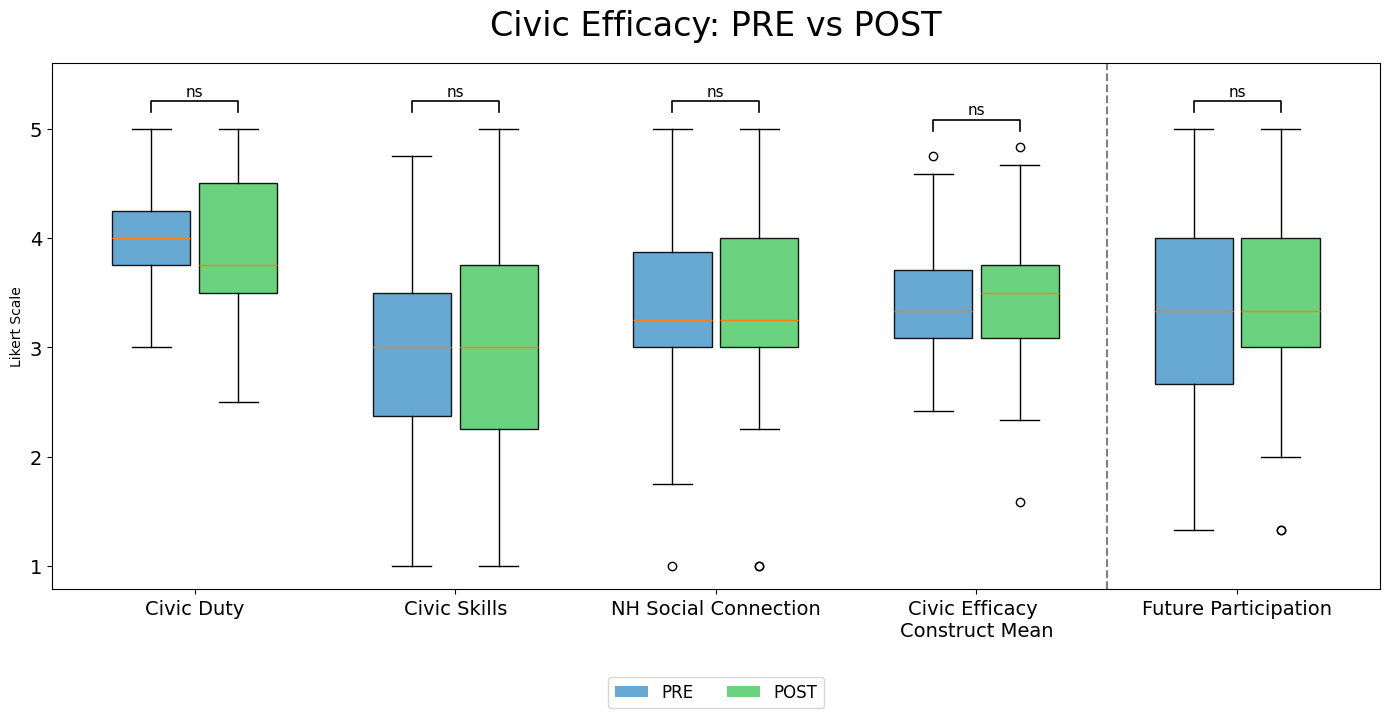

In [34]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch

cols_to_plot = ['civic_duty','civic_skills', 'nh_social_connection', 'ai_civic_mean', 'future_participation']

x_tick_labels = [
    'Civic Duty',
    'Civic Skills',
    'NH Social Connection',
    'Civic Efficacy \nConstruct Mean',
    'Future Participation'
]

pre = output_paired_civic[output_paired_civic['PREPOST'] == 'PRE']
post = output_paired_civic[output_paired_civic['PREPOST'] == 'POST']

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_pre = np.arange(n_cols) * 3
positions_post = positions_pre + 1

all_pre, all_post, sig_labels = [], [], []

for col in cols_to_plot:
    pre_df = pre[['UID', col]].dropna()
    post_df = post[['UID', col]].dropna()
    paired_df = pre_df.merge(post_df, on='UID', suffixes=('_pre', '_post'))

    stat, p_value = stats.wilcoxon(paired_df[f'{col}_pre'], paired_df[f'{col}_post'])

    all_pre.append(paired_df[f'{col}_pre'])
    all_post.append(paired_df[f'{col}_post'])

    if p_value < 0.001:
        sig_labels.append('***')
    elif p_value < 0.01:
        sig_labels.append('**')
    elif p_value < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_pre = ax.boxplot(all_pre, positions=positions_pre, patch_artist=True,
                    widths=0.9, manage_ticks=False)
bp_post = ax.boxplot(all_post, positions=positions_post, patch_artist=True,
                     widths=0.9, manage_ticks=False)

for patch in bp_pre['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_post['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (pre_v, post_v, sig) in enumerate(zip(all_pre, all_post, sig_labels)):
    y_max = max(pre_v.max(), post_v.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_pre[i], positions_post[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_pre + positions_post) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='PRE'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='POST')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=2)

ax.set_title('Civic Efficacy: PRE vs POST', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

# Vertical dashed line before Construct Mean
midpoint = (positions_post[-2] + positions_pre[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [35]:
import pandas as pd
import scipy.stats as stats

cols_to_plot = ['civic_duty', 'civic_skills', 'nh_social_connection', 'future_participation', 'ai_civic_mean']

x_tick_labels = [
    'Civic Duty',
    'Civic Skills',
    'NH Social Connection',
    'Future Participation',
    'Civic Construct Mean'
]

rows = []

for col, label in zip(cols_to_plot, x_tick_labels):
    pre_df = output_paired_civic[output_paired_civic['PREPOST'] == 'PRE'][['UID', col]].dropna()
    post_df = output_paired_civic[output_paired_civic['PREPOST'] == 'POST'][['UID', col]].dropna()
    paired_df = pre_df.merge(post_df, on='UID', suffixes=('_pre', '_post'))

    stat, p_value = stats.wilcoxon(paired_df[f'{col}_pre'], paired_df[f'{col}_post'])

    pre_vals = paired_df[f'{col}_pre']
    post_vals = paired_df[f'{col}_post']

    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    rows.append({
        'Item': label,
        'N (paired)': len(paired_df),
        'Pre Mean (SD)': f"{pre_vals.mean():.2f} ({pre_vals.std():.2f})",
        'Post Mean (SD)': f"{post_vals.mean():.2f} ({post_vals.std():.2f})",
        'W Statistic': f"{stat:.1f}",
        'p-value': f"{p_value:.4f}" if p_value >= 0.001 else "<0.001",
        'Sig.': sig
    })

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Wilcoxon Signed-Rank Test: PRE vs POST — Civic Engagement") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \
    .hide(axis='index')

/tmp/ipykernel_4064/940904695.py:51: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \


Item,N (paired),Pre Mean (SD),Post Mean (SD),W Statistic,p-value,Sig.
Civic Duty,51,4.05 (0.49),3.95 (0.65),371.0,0.2124,ns
Civic Skills,51,2.96 (0.86),3.05 (1.02),416.0,0.6546,ns
NH Social Connection,51,3.26 (0.80),3.40 (0.83),347.0,0.1884,ns
Future Participation,51,3.37 (0.88),3.46 (0.88),293.5,0.1757,ns
Civic Construct Mean,51,3.42 (0.51),3.47 (0.64),555.0,0.5671,ns


## Pre Policy vs. No Policy

In [36]:
all_civic_cols = civic_duty + civic_skills + nh_social_connection + future_participation

for col in all_civic_cols:
    if col in pre_df_original.columns:
        pre_df_original[col] = pd.to_numeric(pre_df_original[col], errors='coerce')

output_pre_civic = pd.DataFrame({
    'School': pre_df_original['School'],
    'civic_duty': pre_df_original[civic_duty].mean(axis=1),
    'civic_skills': pre_df_original[civic_skills].mean(axis=1),
    'nh_social_connection': pre_df_original[nh_social_connection].mean(axis=1),
    'future_participation': pre_df_original[future_participation].mean(axis=1)
})

output_pre_civic['ai_civic_mean'] = output_pre_civic[['civic_duty', 'civic_skills', 'nh_social_connection']].mean(axis=1)

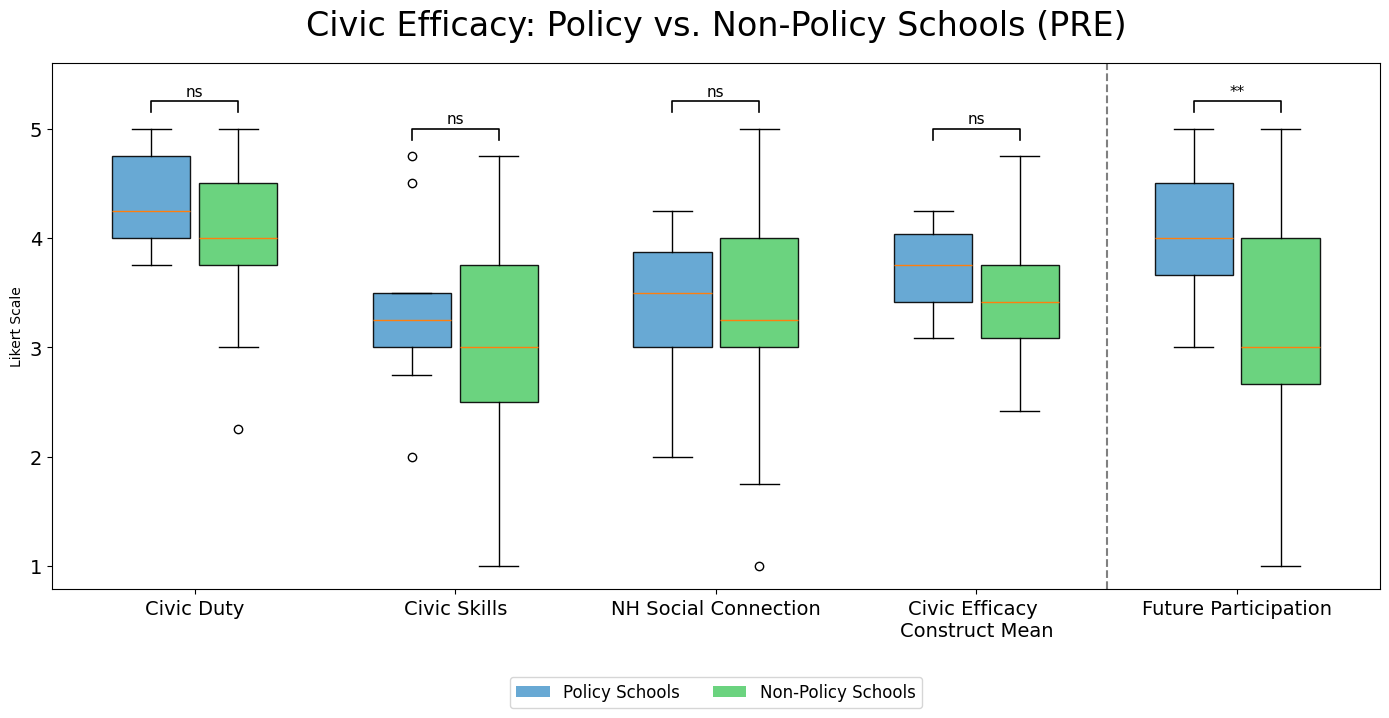

In [37]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch

cols_to_plot = ['civic_duty', 'civic_skills', 'nh_social_connection', 'ai_civic_mean', 'future_participation']

x_tick_labels = [
    'Civic Duty',
    'Civic Skills',
    'NH Social Connection',
    'Civic Efficacy \nConstruct Mean',
    'Future Participation'
]

policy_df = output_pre_civic[output_pre_civic['School'].isin(policy_schools)]
non_policy_df = output_pre_civic[~output_pre_civic['School'].isin(policy_schools)]

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_policy = np.arange(n_cols) * 3
positions_non = positions_policy + 1

all_policy, all_non, sig_labels = [], [], []

for col in cols_to_plot:
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    all_policy.append(policy_vals)
    all_non.append(non_vals)

    if p_value < 0.001:
        sig_labels.append('***')
    elif p_value < 0.01:
        sig_labels.append('**')
    elif p_value < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_policy = ax.boxplot(all_policy, positions=positions_policy, patch_artist=True,
                       widths=0.9, manage_ticks=False)
bp_non = ax.boxplot(all_non, positions=positions_non, patch_artist=True,
                    widths=0.9, manage_ticks=False)

for patch in bp_policy['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_non['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (policy, non, sig) in enumerate(zip(all_policy, all_non, sig_labels)):
    y_max = max(policy.max(), non.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_policy[i], positions_non[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_policy + positions_non) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='Policy Schools'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='Non-Policy Schools')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=2)

ax.set_title('Civic Efficacy: Policy vs. Non-Policy Schools (PRE)', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

# Vertical dashed line before Construct Mean
midpoint = (positions_non[-2] + positions_policy[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [38]:
import pandas as pd
import scipy.stats as stats

cols_to_plot = ['civic_duty', 'civic_skills', 'nh_social_connection', 'ai_civic_mean', 'future_participation']

x_tick_labels = [
    'Civic Duty',
    'Civic Skills',
    'NH Social Connection',
    'Civic Efficacy Construct Mean',
    'Future Participation'
]

policy_df = output_pre_civic[output_pre_civic['School'].isin(policy_schools)]
non_policy_df = output_pre_civic[~output_pre_civic['School'].isin(policy_schools)]

rows = []

for col, label in zip(cols_to_plot, x_tick_labels):
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    rows.append({
        'Item': label,
        'N (Policy)': len(policy_vals),
        'N (Non-Policy)': len(non_vals),
        'Policy Mean (SD)': f"{policy_vals.mean():.2f} ({policy_vals.std():.2f})",
        'Non-Policy Mean (SD)': f"{non_vals.mean():.2f} ({non_vals.std():.2f})",
        'U Statistic': f"{stat:.1f}",
        'p-value': f"{p_value:.4f}" if p_value >= 0.001 else "<0.001",
        'Sig.': sig
    })

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Mann-Whitney U Test: Policy vs. Non-Policy Schools — Civic Efficacy (PRE)") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \
    .hide(axis='index')

/tmp/ipykernel_4064/1251537181.py:51: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \


Item,N (Policy),N (Non-Policy),Policy Mean (SD),Non-Policy Mean (SD),U Statistic,p-value,Sig.
Civic Duty,11,55,4.34 (0.45),4.04 (0.55),393.5,0.1151,ns
Civic Skills,11,55,3.36 (0.76),3.05 (0.84),359.0,0.3328,ns
NH Social Connection,11,55,3.39 (0.72),3.29 (0.84),330.0,0.6396,ns
Civic Efficacy Construct Mean,11,55,3.70 (0.39),3.46 (0.53),389.0,0.1380,ns
Future Participation,11,55,4.03 (0.60),3.24 (0.93),455.0,0.0084,**


## Post Policy vs. No Policy

In [39]:
all_civic_cols = civic_duty + civic_skills + nh_social_connection + future_participation

for col in all_civic_cols:
    if col in post_df_original.columns:
        post_df_original[col] = pd.to_numeric(post_df_original[col], errors='coerce')

output_post_civic = pd.DataFrame({
    'School': post_df_original['School'],
    'civic_duty': post_df_original[civic_duty].mean(axis=1),
    'civic_skills': post_df_original[civic_skills].mean(axis=1),
    'nh_social_connection': post_df_original[nh_social_connection].mean(axis=1),
    'future_participation': post_df_original[future_participation].mean(axis=1)
})

output_post_civic['ai_civic_mean'] = output_post_civic[['civic_duty', 'civic_skills', 'nh_social_connection']].mean(axis=1)

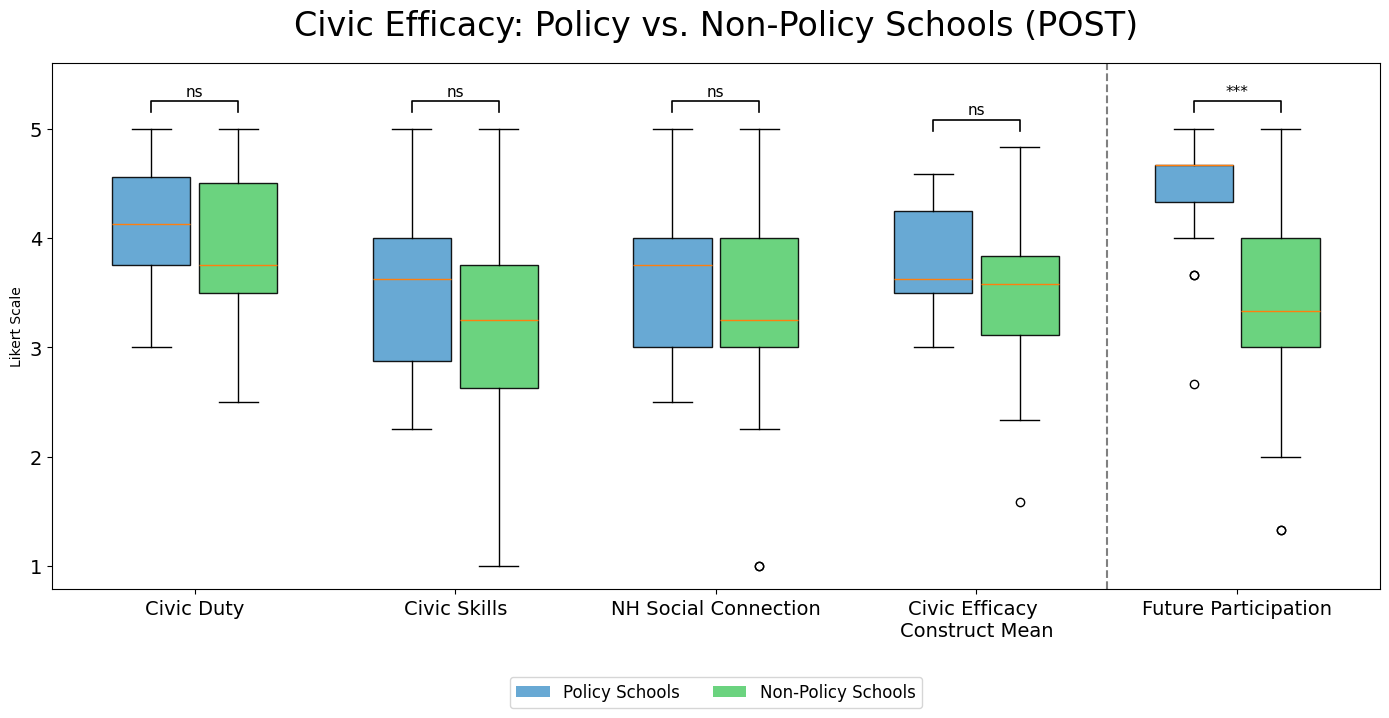

In [40]:
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np
from matplotlib.patches import Patch

cols_to_plot = ['civic_duty', 'civic_skills', 'nh_social_connection', 'ai_civic_mean', 'future_participation']

x_tick_labels = [
    'Civic Duty',
    'Civic Skills',
    'NH Social Connection',
    'Civic Efficacy \nConstruct Mean',
    'Future Participation'
]

policy_df = output_post_civic[output_post_civic['School'].isin(policy_schools)]
non_policy_df = output_post_civic[~output_post_civic['School'].isin(policy_schools)]

fig, ax = plt.subplots(figsize=(14, 7))

n_cols = len(cols_to_plot)
positions_policy = np.arange(n_cols) * 3
positions_non = positions_policy + 1

all_policy, all_non, sig_labels = [], [], []

for col in cols_to_plot:
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    all_policy.append(policy_vals)
    all_non.append(non_vals)

    if p_value < 0.001:
        sig_labels.append('***')
    elif p_value < 0.01:
        sig_labels.append('**')
    elif p_value < 0.05:
        sig_labels.append('*')
    else:
        sig_labels.append('ns')

# Plot boxes
bp_policy = ax.boxplot(all_policy, positions=positions_policy, patch_artist=True,
                       widths=0.9, manage_ticks=False)
bp_non = ax.boxplot(all_non, positions=positions_non, patch_artist=True,
                    widths=0.9, manage_ticks=False)

for patch in bp_policy['boxes']:
    patch.set_facecolor('#58a0d0')
    patch.set_alpha(0.9)
for patch in bp_non['boxes']:
    patch.set_facecolor('#5bcf71')
    patch.set_alpha(0.9)

# Significance brackets
for i, (policy, non, sig) in enumerate(zip(all_policy, all_non, sig_labels)):
    y_max = max(policy.max(), non.max())
    y1 = y_max + 0.15
    y2 = y1 + 0.1
    x1, x2 = positions_policy[i], positions_non[i]
    ax.plot([x1, x1, x2, x2], [y1, y2, y2, y1], lw=1.2, color='black')
    ax.text((x1 + x2) / 2, y2 + 0.02, sig, ha='center', va='bottom', fontsize=11)

# X ticks
tick_positions = (positions_policy + positions_non) / 2
ax.set_xticks(tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=0, ha='center', fontsize=14)

# Y-axis
ax.tick_params(axis='y', labelsize=14)
existing_yticks = [t for t in ax.get_yticks() if ax.get_ylim()[0] <= t <= 5]
ax.set_ylim(top=5.6)
ax.set_yticks(existing_yticks)

# Legend at bottom
legend_elements = [Patch(facecolor='#58a0d0', alpha=0.9, label='Policy Schools'),
                   Patch(facecolor='#5bcf71', alpha=0.9, label='Non-Policy Schools')]
ax.legend(handles=legend_elements, fontsize=12, loc='upper center',
          bbox_to_anchor=(0.5, -0.15), ncol=2)

ax.set_title('Civic Efficacy: Policy vs. Non-Policy Schools (POST)', fontsize=24, pad=20)
ax.set_ylabel('Likert Scale')

# Vertical dashed line before Construct Mean
midpoint = (positions_non[-2] + positions_policy[-1]) / 2
ax.axvline(x=midpoint, color='gray', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

In [41]:
import pandas as pd
import scipy.stats as stats

cols_to_plot = ['civic_duty', 'civic_skills', 'nh_social_connection', 'ai_civic_mean', 'future_participation']

x_tick_labels = [
    'Civic Duty',
    'Civic Skills',
    'NH Social Connection',
    'Civic Efficacy Construct Mean',
    'Future Participation'
]

policy_df = output_post_civic[output_post_civic['School'].isin(policy_schools)]
non_policy_df = output_post_civic[~output_post_civic['School'].isin(policy_schools)]

rows = []

for col, label in zip(cols_to_plot, x_tick_labels):
    policy_vals = policy_df[col].dropna()
    non_vals = non_policy_df[col].dropna()

    stat, p_value = stats.mannwhitneyu(policy_vals, non_vals, alternative='two-sided')

    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = 'ns'

    rows.append({
        'Item': label,
        'N (Policy)': len(policy_vals),
        'N (Non-Policy)': len(non_vals),
        'Policy Mean (SD)': f"{policy_vals.mean():.2f} ({policy_vals.std():.2f})",
        'Non-Policy Mean (SD)': f"{non_vals.mean():.2f} ({non_vals.std():.2f})",
        'U Statistic': f"{stat:.1f}",
        'p-value': f"{p_value:.4f}" if p_value >= 0.001 else "<0.001",
        'Sig.': sig
    })

wilcoxon_df = pd.DataFrame(rows)

wilcoxon_df.style \
    .set_caption("Mann-Whitney U Test: Policy vs. Non-Policy Schools — Civic Efficacy (POST)") \
    .set_properties(**{'text-align': 'center'}) \
    .set_properties(subset=['Item'], **{'text-align': 'left'}) \
    .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \
    .hide(axis='index')

/tmp/ipykernel_4064/1203147446.py:51: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'color: red; font-weight: bold' if v in ('*', '**', '***') else '', subset=['Sig.']) \


Item,N (Policy),N (Non-Policy),Policy Mean (SD),Non-Policy Mean (SD),U Statistic,p-value,Sig.
Civic Duty,20,51,4.16 (0.61),3.94 (0.67),619.0,0.1614,ns
Civic Skills,20,51,3.50 (0.89),3.11 (0.93),627.0,0.1343,ns
NH Social Connection,20,51,3.70 (0.70),3.38 (0.78),619.0,0.1612,ns
Civic Efficacy Construct Mean,20,51,3.79 (0.49),3.48 (0.62),653.5,0.0670,ns
Future Participation,20,51,4.42 (0.57),3.39 (0.83),857.5,<0.001,***
